## Chapter 3 - Methodological Foundations for Volatility Regime Detection

Data: 
- S&P 500 (US)

- NASDAQ Composite (US, tech-heavy)

- FTSE 100 (UK)

- DAX (Germany)

- Nikkei 225 (Japan)

Time span: From January 2015 to December 2023, about 2,250 trading days per index.

### Baseline 1

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.mixture import GaussianMixture
from scipy.stats import skew, kurtosis

DATA_DIR = Path("./")  # <- change to your folder

INDEX_FILES = {
    "SP500":   "SP500_daily_2015-01-01_to_2023-12-31.csv",
    "NASDAQ":  "NASDAQ_daily_2015-01-01_to_2023-12-31.csv",
    "FTSE100": "FTSE100_daily_2015-01-01_to_2023-12-31.csv",
    "DAX":     "DAX_daily_2015-01-01_to_2023-12-31.csv",
    "Nikkei225": "Nikkei225_daily_2015-01-01_to_2023-12-31.csv",
}

TRAIN_END = pd.Timestamp("2020-12-31")
TEST_START = pd.Timestamp("2021-01-01")


def load_index(name, fname):
    """Load single index CSV and return tidy DataFrame."""
    path = DATA_DIR / fname
    df = pd.read_csv(path)

    # Your header row is: Price | Close | High | Low | Open | Volume
    # Column 'Price' actually stores the calendar date.
    df.rename(columns={"Price": "Date"}, inplace=True)

    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.sort_values("Date").reset_index(drop=True)

    # ensure numeric
    for col in ["Close", "High", "Low", "Open", "Volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Index"] = name
    return df[["Date", "Index", "Open", "High", "Low", "Close", "Volume"]]


def load_all_indices():
    frames = []
    for name, fname in INDEX_FILES.items():
        frames.append(load_index(name, fname))
    return pd.concat(frames, ignore_index=True)

def compute_features(df):
    """
    For each index separately:
      - log returns
      - rolling realised volatility (5, 10, 20, 60 days, annualised)
      - Parkinson realised range estimator (20-day window)
      - rolling skewness / kurtosis of returns (20-day window)
      - 60-day max drawdown
    """

    def features_for_one_index(sub):
        sub = sub.sort_values("Date").copy()

        # log returns from close prices
        sub["ret"] = np.log(sub["Close"]).diff()

        # realised volatility (annualised)
        windows = [5, 10, 20, 60]
        for w in windows:
            sub[f"RV_{w}"] = (
                sub["ret"].rolling(w).std() * np.sqrt(252)
            )

        # Parkinson daily variance
        # sigma_P^2 = (1/(4*ln 2)) * (ln(H/L))^2
        hl = np.log(sub["High"] / sub["Low"])
        sub["parkinson_var"] = (hl ** 2) / (4 * np.log(2))

        # 20-day realised Parkinson volatility (annualised)
        sub["RV_parkinson_20"] = (
            np.sqrt(sub["parkinson_var"].rolling(20).mean()) * np.sqrt(252)
        )

        # higher moments: 20-day skewness & kurtosis of returns
        sub["skew_20"] = sub["ret"].rolling(20).apply(
            lambda x: skew(x, bias=False), raw=False
        )
        sub["kurt_20"] = sub["ret"].rolling(20).apply(
            lambda x: kurtosis(x, fisher=False, bias=False), raw=False
        )

        # 60-day max drawdown (peak-to-trough loss, positive number)
        window = 60

        def max_drawdown(x):
            # x is array of prices
            cummax = np.maximum.accumulate(x)
            dd = x / cummax - 1.0
            return -dd.min()   # positive magnitude

        sub["dd_60"] = sub["Close"].rolling(window).apply(
            max_drawdown, raw=False
        )

        return sub

    return df.groupby("Index", group_keys=False).apply(features_for_one_index)



def standardise_by_index(train_test_df, feature_cols):
    """
    z-normalise features separately for each index using
    training period moments only.
    """
    out = train_test_df.copy()
    for name, grp in out.groupby("Index"):
        mask_train = grp["Date"] <= TRAIN_END
        mu = grp.loc[mask_train, feature_cols].mean()
        sd = grp.loc[mask_train, feature_cols].std(ddof=0)

        out.loc[grp.index, feature_cols] = (grp[feature_cols] - mu) / sd
    return out



def fit_gmm_with_bic(X_train, K_min=2, K_max=6, random_state=42):
    """Fit GMM with K chosen by BIC."""
    best_gmm = None
    best_bic = np.inf
    best_K = None

    for K in range(K_min, K_max + 1):
        gmm = GaussianMixture(
            n_components=K,
            covariance_type="full",
            random_state=random_state,
        )
        gmm.fit(X_train)
        bic = gmm.bic(X_train)
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
            best_K = K

    return best_gmm, best_K, best_bic


def run_gmm_baseline(df_features, feature_cols, rv_col="RV_20"):
    """
    Run Baseline I (GMM-EM) per index.
    Returns a dict of results and prints key diagnostics.
    """
    results = {}

    for name, sub in df_features.groupby("Index"):
        sub = sub.dropna(subset=feature_cols + [rv_col]).reset_index(drop=True)

        # train/test split
        train_mask = sub["Date"] <= TRAIN_END
        test_mask = sub["Date"] >= TEST_START

        X_train = sub.loc[train_mask, feature_cols].values
        X_all = sub[feature_cols].values

        # ---- Fit GMM with BIC-selected K ----
        gmm, K_opt, bic = fit_gmm_with_bic(X_train)

        # posterior probabilities and hard labels
        gamma = gmm.predict_proba(X_all)             # (T, K)
        hard_labels = gamma.argmax(axis=1)           # (T,)

        # entropy of posterior (uncertainty)
        entropy = -(gamma * np.log(gamma + 1e-12)).sum(axis=1)

        # switching frequency & mean regime run length
        z = hard_labels
        switches = (z[1:] != z[:-1]).astype(int)
        psi = switches.mean()                        # normalised switching freq.

        # run lengths
        run_lengths = []
        current_len = 1
        for i in range(1, len(z)):
            if z[i] == z[i - 1]:
                current_len += 1
            else:
                run_lengths.append(current_len)
                current_len = 1
        run_lengths.append(current_len)
        mean_run = np.mean(run_lengths)

        # ---- Regime-aware volatility forecasting ----
        # realised volatility series to forecast (squared)
        rv2 = sub[rv_col].values ** 2

        # compute regime-conditional mean variance using TRAIN period only
        train_labels = hard_labels[train_mask.values]
        train_rv2 = rv2[train_mask.values]

        sigma2_k = []
        for k in range(K_opt):
            idx_k = train_labels == k
            sigma2_k.append(train_rv2[idx_k].mean())
        sigma2_k = np.array(sigma2_k)

        # constant-variance benchmark
        const_sigma2 = train_rv2.mean()

        # one-step-ahead forecasts on TEST set
        test_idx = np.where(test_mask.values)[0]
        # for each t in test, forecast variance at t+1 using regime at t
        gmm_forecasts = []
        const_forecasts = []
        realised_future = []

        for i in test_idx[:-1]:  # last point has no t+1
            k_t = hard_labels[i]
            gmm_forecasts.append(sigma2_k[k_t])
            const_forecasts.append(const_sigma2)
            realised_future.append(rv2[i + 1])

        gmm_forecasts = np.array(gmm_forecasts)
        const_forecasts = np.array(const_forecasts)
        realised_future = np.array(realised_future)

        mse_gmm = np.mean((gmm_forecasts - realised_future) ** 2)
        mse_const = np.mean((const_forecasts - realised_future) ** 2)

        results[name] = {
            "gmm": gmm,
            "K_opt": K_opt,
            "bic": bic,
            "gamma": gamma,
            "hard_labels": hard_labels,
            "entropy": entropy,
            "switching_freq": psi,
            "mean_run_length": mean_run,
            "mse_gmm": mse_gmm,
            "mse_const": mse_const,
            "df": sub,
        }

        print(f"\n=== {name} ===")
        print(f"Optimal K (BIC): {K_opt}")
        print(f"Switching frequency Ψ: {psi:.3f}")
        print(f"Mean regime run length E[L]: {mean_run:.1f} days")
        print(f"MSE (regime-aware): {mse_gmm:.4e}")
        print(f"MSE (constant var): {mse_const:.4e}")

    return results



if __name__ == "__main__":
   
    df_raw = load_all_indices()

   
    df_feat = compute_features(df_raw)


    FEATURE_COLS = [
        "RV_5", "RV_10", "RV_20", "RV_60",
        "RV_parkinson_20",
        "skew_20", "kurt_20",
        "dd_60",
    ]


    df_feat_std = standardise_by_index(df_feat, FEATURE_COLS)


    baseline_results = run_gmm_baseline(
        df_feat_std, feature_cols=FEATURE_COLS, rv_col="RV_20"
    )



C:\Users\fghanduri\AppData\Local\Temp\ipykernel_45024\1198489450.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("Index", group_keys=False).apply(features_for_one_index)



=== DAX ===
Optimal K (BIC): 6
Switching frequency Ψ: 0.072
Mean regime run length E[L]: 13.8 days
MSE (regime-aware): 7.9351e-01
MSE (constant var): 1.3643e+00

=== FTSE100 ===
Optimal K (BIC): 6
Switching frequency Ψ: 0.090
Mean regime run length E[L]: 11.1 days
MSE (regime-aware): 1.5737e-01
MSE (constant var): 6.7755e-01

=== NASDAQ ===
Optimal K (BIC): 6
Switching frequency Ψ: 0.070
Mean regime run length E[L]: 14.1 days
MSE (regime-aware): 1.0774e+00
MSE (constant var): 1.2372e+00

=== Nikkei225 ===
Optimal K (BIC): 6
Switching frequency Ψ: 0.088
Mean regime run length E[L]: 11.3 days
MSE (regime-aware): 1.1091e+00
MSE (constant var): 7.8443e-01

=== SP500 ===
Optimal K (BIC): 6
Switching frequency Ψ: 0.057
Mean regime run length E[L]: 17.4 days
MSE (regime-aware): 2.5434e-01
MSE (constant var): 7.6229e-01


##### Baseline 1: Results

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


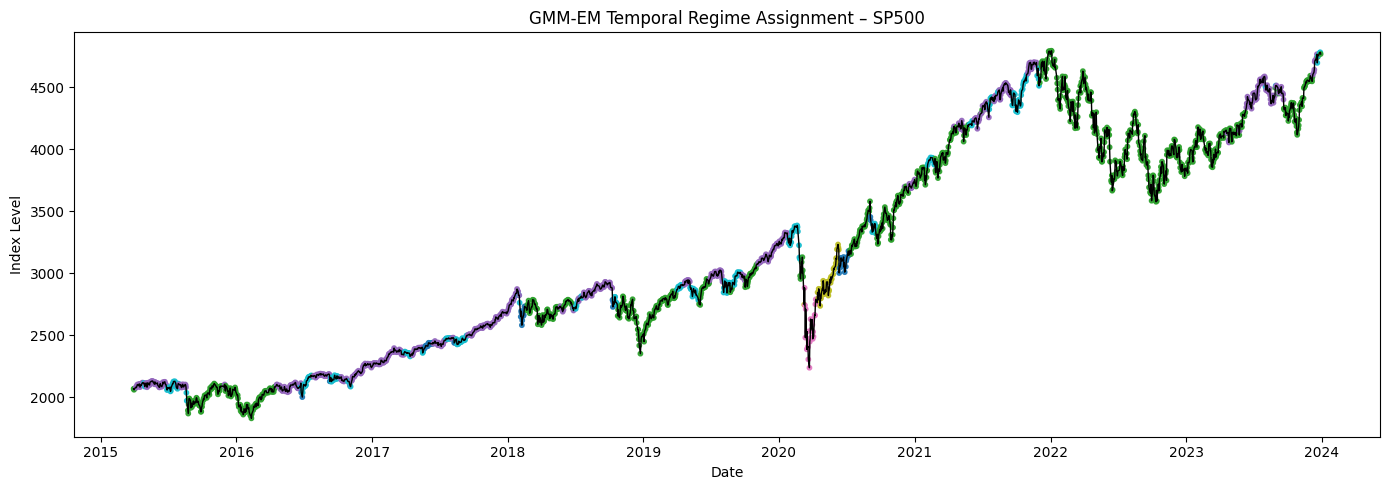

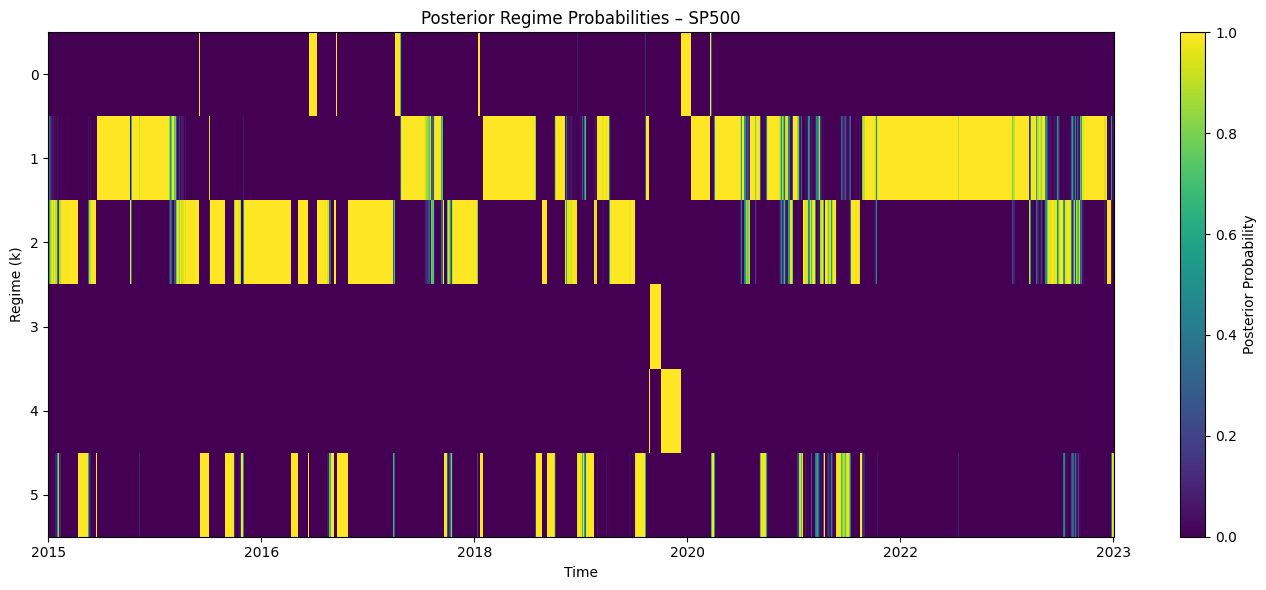

,Regime,Count,Mean RV20,Mean Drawdown60,Mean Kurtosis,Mean Skewness,Mean Posterior Entropy
0,0,59,0.395579,-0.171134,3.106342,-2.630421,1.390064e-02
1,1,1030,0.314547,0.390704,-0.373272,0.188409,6.421660e-02
2,2,747,-0.536045,-0.546164,-0.255501,0.499704,1.162908e-01
3,3,24,5.905699,3.788050,-0.446899,0.131589,2.770718e-08
4,4,42,1.626287,3.495884,-0.504468,0.262855,3.174376e-07
5,5,302,-0.114114,-0.431437,0.644768,-0.994997,1.474063e-01


In [5]:
def plot_regime_timeline(results, index_name="SP500", savepath=None):
    res = results[index_name]
    df = res["df"].copy()
    df["regime"] = res["hard_labels"]

    plt.figure(figsize=(14,5))
    plt.plot(df["Date"], df["Close"], color="black", linewidth=1, label="Price")

    scatter = plt.scatter(
        df["Date"],
        df["Close"],
        c=df["regime"],
        cmap="tab10",
        s=10,
        alpha=0.9
    )

    plt.title(f"GMM-EM Temporal Regime Assignment – {index_name}")
    plt.xlabel("Date")
    plt.ylabel("Index Level")
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


# Example usage
plot_regime_timeline(baseline_results, "SP500", savepath="fig_gmm_timeline_sp500.png")

def plot_regime_probabilities(results, index_name="SP500", savepath=None):
    res = results[index_name]
    df = res["df"].copy()
    gamma = res["gamma"]  # (T x K)
    K = gamma.shape[1]

    fig, ax = plt.subplots(figsize=(14,6))
    im = ax.imshow(gamma.T, aspect="auto", cmap="viridis",
                   interpolation="nearest")

    ax.set_title(f"Posterior Regime Probabilities – {index_name}")
    ax.set_ylabel("Regime (k)")
    ax.set_xlabel("Time")
    ax.set_yticks(np.arange(K))
    ax.set_xticks(np.linspace(0, len(df)-1, 6))
    ax.set_xticklabels(
        pd.to_datetime(df["Date"]).dt.strftime("%Y").iloc[
            np.linspace(0, len(df)-1, 6).astype(int)
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Posterior Probability")

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


# Example
plot_regime_probabilities(baseline_results, "SP500",
                          savepath="fig_gmm_probabilities_sp500.png")

def regime_summary_table(results, index_name="SP500",
                         rv_col="RV_20"):
    res = results[index_name]
    df = res["df"].copy()
    df["regime"] = res["hard_labels"]
    gamma = res["gamma"]
    entropy = res["entropy"]

    summary = []

    for k in sorted(df["regime"].unique()):
        sub = df[df["regime"] == k]

        summary.append({
            "Regime": k,
            "Count": len(sub),
            "Mean RV20": np.mean(sub[rv_col]),
            "Mean Drawdown60": np.mean(sub["dd_60"]),
            "Mean Kurtosis": np.mean(sub["kurt_20"]),
            "Mean Skewness": np.mean(sub["skew_20"]),
            "Mean Posterior Entropy": np.mean(entropy[sub.index])
        })

    table = pd.DataFrame(summary)
    return table


# Example
table_sp500 = regime_summary_table(baseline_results, "SP500")
table_sp500





Processing DAX ...


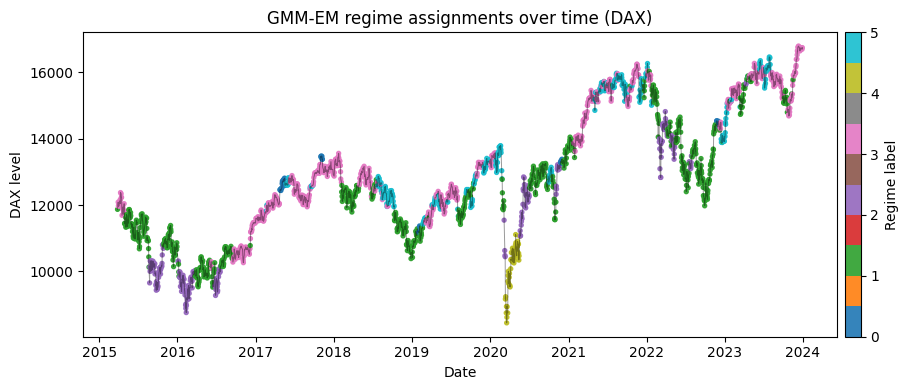

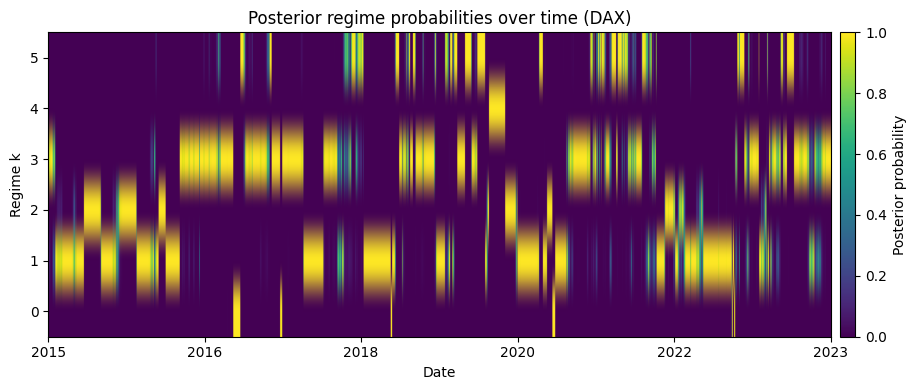


Processing FTSE100 ...


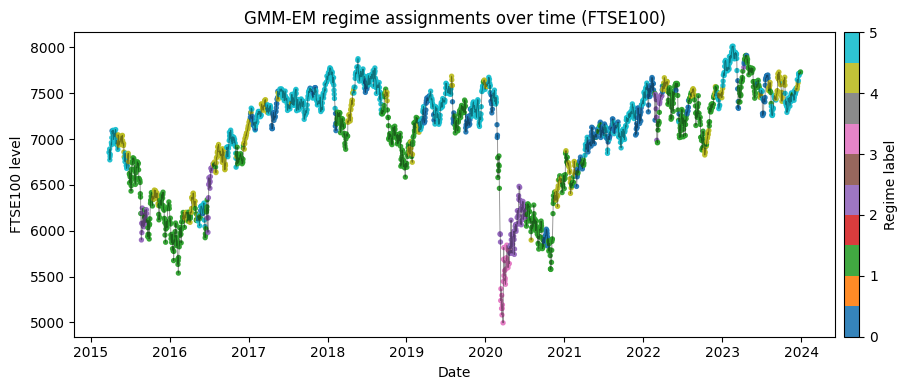

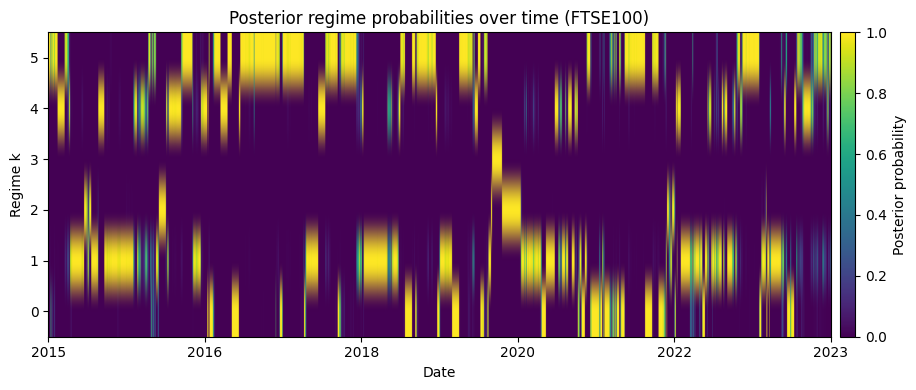


Processing NASDAQ ...


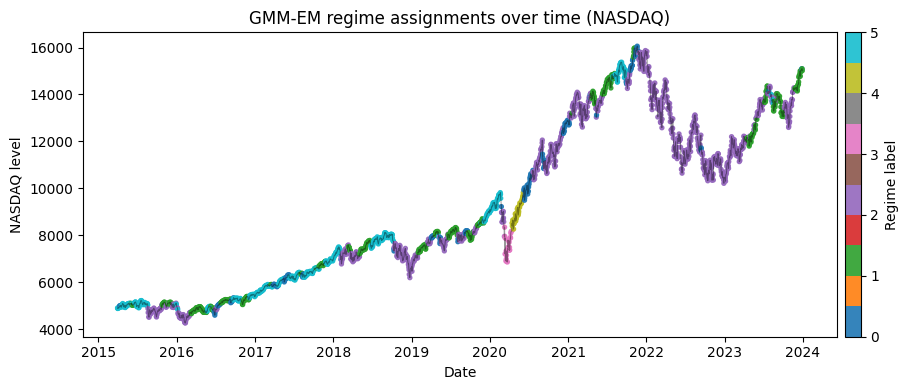

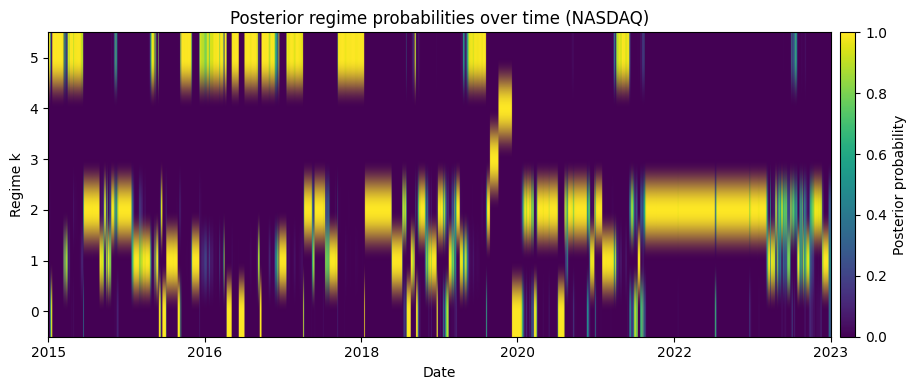


Processing Nikkei225 ...


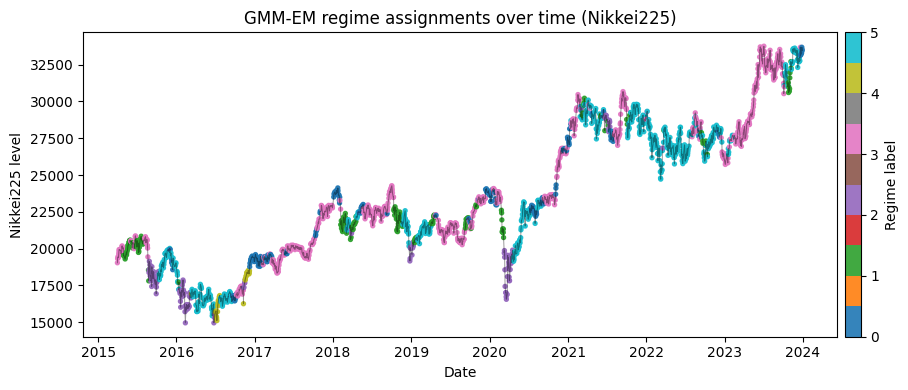

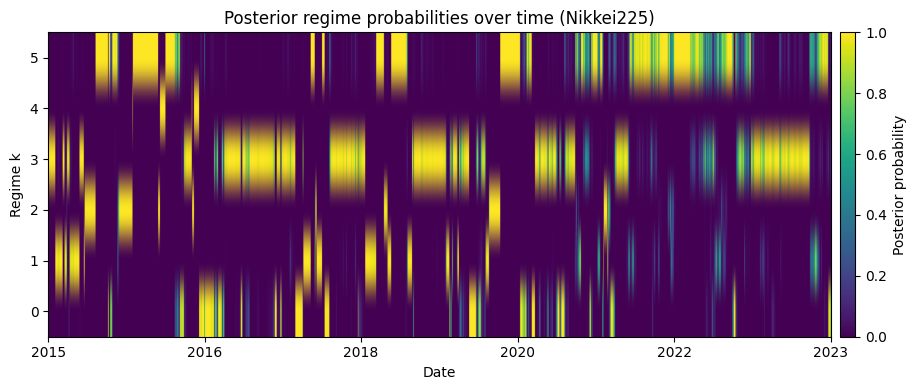


Processing SP500 ...


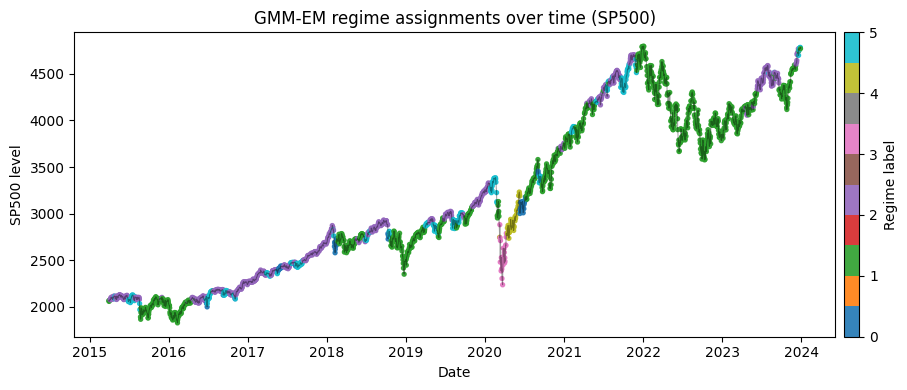

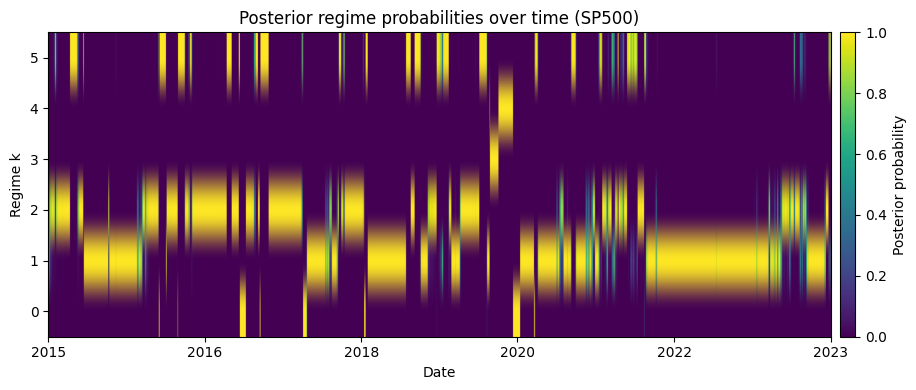

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_gmm_timeline(baseline_results, index_name,
                      outfile=None):
    res = baseline_results[index_name]
    df = res["df"].copy()
    df["regime"] = res["hard_labels"]

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(df["Date"], df["Close"], color="black", linewidth=0.7, alpha=0.4)

    sc = ax.scatter(df["Date"], df["Close"],
                    c=df["regime"], cmap="tab10",
                    s=8, alpha=0.9)

    ax.set_xlabel("Date")
    ax.set_ylabel(f"{index_name} level")
    ax.set_title(f"GMM-EM regime assignments over time ({index_name})")

    cbar = fig.colorbar(sc, ax=ax, pad=0.01)
    cbar.set_label("Regime label")

    fig.tight_layout()
    if outfile is not None:
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()


def plot_gmm_posteriors(baseline_results, index_name,
                        outfile=None):
    res = baseline_results[index_name]
    df = res["df"].copy()
    gamma = res["gamma"]
    K = gamma.shape[1]
    T = gamma.shape[0]

    fig, ax = plt.subplots(figsize=(10, 4))

    im = ax.imshow(
        gamma.T,
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )

    tick_positions = np.linspace(0, T - 1, 6, dtype=int)
    tick_labels = df["Date"].dt.strftime("%Y").iloc[tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel("Date")

    ax.set_yticks(range(K))
    ax.set_yticklabels([f"{k}" for k in range(K)])
    ax.set_ylabel("Regime k")

    ax.set_title(f"Posterior regime probabilities over time ({index_name})")

    cbar = fig.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label("Posterior probability")

    fig.tight_layout()
    if outfile is not None:
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()


def gmm_regime_summary_table(baseline_results, index_name,
                             rv_col="RV_20"):
    res = baseline_results[index_name]
    df = res["df"].copy()
    df["regime"] = res["hard_labels"]
    entropy = res["entropy"]

    rows = []
    for k in sorted(df["regime"].unique()):
        sub = df[df["regime"] == k]
        rows.append({
            "Index": index_name,
            "Regime": k,
            "Count": len(sub),
            "Mean RV20": sub[rv_col].mean(),
            "Mean Drawdown60": sub["dd_60"].mean(),
            "Mean Kurtosis": sub["kurt_20"].mean(),
            "Mean Skewness": sub["skew_20"].mean(),
            "Mean Posterior Entropy": entropy[sub.index].mean()
        })

    return pd.DataFrame(rows)


def print_latex_table(table, caption=None, label=None):
    print(
        table.round(4).to_latex(
            index=False,
            caption=caption or "Descriptive statistics of inferred regimes.",
            label=label or "tab:gmm_summary"
        )
    )


def evaluate_all_indices(baseline_results,
                         fig_dir=".",
                         rv_col="RV_20"):
    """Create plots & tables for all indices."""
    all_regime_rows = []
    perf_rows = []

    for index_name in baseline_results.keys():
        print(f"\nProcessing {index_name} ...")

        # ---- Figures for each index ----
        tl_path = f"{fig_dir}/fig_gmm_timeline_{index_name.lower()}.pdf"
        pb_path = f"{fig_dir}/fig_gmm_probabilities_{index_name.lower()}.pdf"

        plot_gmm_timeline(baseline_results, index_name, outfile=tl_path)
        plot_gmm_posteriors(baseline_results, index_name, outfile=pb_path)

        # ---- Regime summary rows ----
        table_idx = gmm_regime_summary_table(
            baseline_results, index_name, rv_col=rv_col
        )
        all_regime_rows.append(table_idx)

        # ---- Forecasting performance row ----
        res = baseline_results[index_name]
        perf_rows.append({
            "Index": index_name,
            "K_opt": res["K_opt"],
            "SwitchingFreq": res["switching_freq"],
            "MeanRunLength": res["mean_run_length"],
            "MSE_RegimeAware": res["mse_gmm"],
            "MSE_ConstantVar": res["mse_const"],
            "MSE_Ratio_Regime_over_Const": res["mse_gmm"] / res["mse_const"]
        })

    # Combine tables
    regime_table_all = pd.concat(all_regime_rows, ignore_index=True)
    perf_table = pd.DataFrame(perf_rows)

    return regime_table_all, perf_table



regime_table_all, perf_table_all = evaluate_all_indices(
    baseline_results,
    fig_dir=".",      # or "figures/ch3" etc.
    rv_col="RV_20"
)



### Baseline 2

In [16]:
pip install fastdtw

Note: you may need to restart the kernel to use updated packages.Collecting fastdtw
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fastdtw: filename=fastdtw-0.3.4-py3-none-any.whl size=3630 sha256=e044f5b07aff46a7fdbb1ae3e9845fe6fe1092f7f142b1fdc4b7cd4b56b72440
  Stored in directory: c:\users\fghanduri\appdata\local\pip\cache\wheels\2c\9e\6d\6c419b5fe1b720cf2f9c7b20ea119dc201878ea890ba26221f
Successfully built fastdtw




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from tqdm import tqdm


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from tqdm import tqdm
# from fastdtw import fastdtw



# --------------------------------------------------
# 1. CONFIG (your part)
# --------------------------------------------------
DATA_DIR = Path("./")

INDEX_FILES = {
    "SP500":     "SP500_daily_2015-01-01_to_2023-12-31.csv",
    "NASDAQ":    "NASDAQ_daily_2015-01-01_to_2023-12-31.csv",
    "FTSE100":   "FTSE100_daily_2015-01-01_to_2023-12-31.csv",
    "DAX":       "DAX_daily_2015-01-01_to_2023-12-31.csv",
    "Nikkei225": "Nikkei225_daily_2015-01-01_to_2023-12-31.csv",
}

TRAIN_END  = pd.Timestamp("2020-12-31")
TEST_START = pd.Timestamp("2021-01-01")


def load_index(name, fname):
    """Load single index CSV and return tidy DataFrame."""
    path = DATA_DIR / fname
    df = pd.read_csv(path)

    # Column 'Price' actually stores the calendar date.
    df.rename(columns={"Price": "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.sort_values("Date").reset_index(drop=True)

    # ensure numeric
    for col in ["Close", "High", "Low", "Open", "Volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Index"] = name
    return df[["Date", "Index", "Open", "High", "Low", "Close", "Volume"]]

# --------------------------------------------------
# 2. FEATURE ENGINEERING (RV20 etc.)
# --------------------------------------------------

def add_vol_features(df, rv_window=20):
    """Add log-returns and 20-day realised variance RV20."""
    df = df.copy()
    df["log_ret"] = np.log(df["Close"]).diff()
    df["RV20"] = df["log_ret"].rolling(rv_window).var()  # adjust if you annualise
    return df

# --------------------------------------------------
# 3. DTW + HC helpers
# --------------------------------------------------

def dtw_distance(v, w):
    """Classic DTW with squared Euclidean local cost."""
    L1, L2 = len(v), len(w)
    dp = np.full((L1 + 1, L2 + 1), np.inf)
    dp[0, 0] = 0.0

    for i in range(1, L1 + 1):
        for j in range(1, L2 + 1):
            cost = (v[i - 1] - w[j - 1]) ** 2
            dp[i, j] = cost + min(dp[i - 1, j], dp[i, j - 1], dp[i - 1, j - 1])

    return dp[L1, L2]

# def dtw_distance(v, w):
#     d, _ = fastdtw(v, w)
#     return d


def build_segments(df, rv_col="RV20", L=60):
    """Build overlapping L-day segments from a volatility series."""
    x = df[rv_col].values
    segments = []
    idx_map = []
    for i in range(len(x) - L + 1):
        seg = x[i:i + L]
        if np.isnan(seg).any():
            continue
        segments.append(seg)
        idx_map.append((df["Date"].iloc[i], df["Date"].iloc[i + L - 1]))
    return np.array(segments), idx_map


def dtw_distance_matrix(segments):
    """Compute full N x N DTW distance matrix."""
    N = len(segments)
    D = np.zeros((N, N))
    for i in tqdm(range(N), desc="DTW matrix"):
        for j in range(i + 1, N):
            d = dtw_distance(segments[i], segments[j])
            D[i, j] = D[j, i] = d
    return D


def run_dtw_hc(D, n_clusters=4):
    """Hierarchical clustering (average linkage) on DTW distances."""
    condensed = squareform(D)
    Z = linkage(condensed, method="average")
    labels = fcluster(Z, n_clusters, criterion="maxclust")
    return Z, labels


def plot_dendrogram(Z, index_name, out_dir=Path(".")):
    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode="level", p=10)
    plt.title(f"DTW-HC Dendrogram – {index_name}")
    plt.ylabel("DTW distance")
    plt.tight_layout()
    fname = out_dir / f"fig_dtw_dendrogram_{index_name.lower()}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved dendrogram to {fname}")


def cluster_prototypes(segments, labels):
    """Median trajectory per cluster."""
    prototypes = {}
    for k in np.unique(labels):
        cluster = segments[labels == k]
        prototypes[k] = np.median(cluster, axis=0)
    return prototypes


def plot_prototypes(prototypes, index_name, out_dir=Path(".")):
    plt.figure(figsize=(10, 5))
    for k, proto in sorted(prototypes.items()):
        plt.plot(proto, label=f"Cluster {k}")
    plt.title(f"DTW-HC Prototype Trajectories – {index_name}")
    plt.xlabel("Days")
    plt.ylabel("Volatility (RV20)")
    plt.legend()
    plt.tight_layout()
    fname = out_dir / f"fig_dtw_prototypes_{index_name.lower()}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved prototypes to {fname}")


def cluster_statistics(segments, labels):
    """Simple summary: count, mean RV, mean within-window drawdown."""
    rows = []
    for k in sorted(np.unique(labels)):
        cluster = segments[labels == k]
        # mean over all points in all segments
        mean_rv = cluster.mean()
        # rough within-window drawdown: min - max per segment
        dd = cluster.min(axis=1) - cluster.max(axis=1)
        rows.append([k, len(cluster), mean_rv, dd.mean()])
    return pd.DataFrame(rows, columns=["Cluster", "Count", "Mean RV20", "Mean Drawdown"])


def assign_cluster(seg, prototypes):
    """Assign a single segment to nearest prototype under DTW."""
    best_k, best_d = None, np.inf
    for k, proto in prototypes.items():
        d = dtw_distance(seg, proto)
        if d < best_d:
            best_d, best_k = d, k
    return best_k


def dtw_forecast(df_test, prototypes, rv_col="RV20", L=60):
    """1-step-ahead forecast using cluster average variance."""
    x = df_test[rv_col].values
    preds, true = [], []

    for i in range(len(x) - L):
        seg = x[i:i + L]
        if np.isnan(seg).any():
            continue
        future = x[i + L]
        k = assign_cluster(seg, prototypes)
        pred = np.mean(prototypes[k])

        preds.append(pred)
        true.append(future)

    true = np.asarray(true)
    preds = np.asarray(preds)

    mse_regime = np.mean((preds - true) ** 2)
    const = np.mean(true)
    mse_const = np.mean((const - true) ** 2)
    return mse_regime, mse_const

# --------------------------------------------------
# 4. MAIN LOOP OVER ALL INDICES
# --------------------------------------------------

all_results = {}

for name, fname in INDEX_FILES.items():
    print(f"\n===== {name} =====")
    df = load_index(name, fname)
    df = add_vol_features(df)

    # Train / test split
    df_train = df[df["Date"] <= TRAIN_END].dropna(subset=["RV20"]).reset_index(drop=True)
    df_test  = df[df["Date"] >= TEST_START].dropna(subset=["RV20"]).reset_index(drop=True)

    print(f"Train rows: {len(df_train)}, Test rows: {len(df_test)}")

    # Build segments on training set
    L = 60
    segments, idx_map = build_segments(df_train, rv_col="RV20", L=L)
    print(f"Number of {L}-day segments (train): {len(segments)}")

    # DTW distance matrix + clustering
    D = dtw_distance_matrix(segments)
    Z, labels = run_dtw_hc(D, n_clusters=4)

    # Plots
    plot_dendrogram(Z, name, out_dir=DATA_DIR)
    prototypes = cluster_prototypes(segments, labels)
    plot_prototypes(prototypes, name, out_dir=DATA_DIR)

    # Summary table
    stats = cluster_statistics(segments, labels)
    print(stats)

    # Forecast evaluation
    mse_regime, mse_const = dtw_forecast(df_test, prototypes, rv_col="RV20", L=L)
    print(f"MSE (regime-aware): {mse_regime:.4e}")
    print(f"MSE (constant var): {mse_const:.4e}")

    # Store everything for later LaTeX / thesis use
    all_results[name] = {
        "stats": stats,
        "mse_regime": mse_regime,
        "mse_const": mse_const,
    }



===== SP500 =====
Train rows: 1491, Test rows: 753
Number of 60-day segments (train): 1432


DTW matrix: 100%|██████████| 1432/1432 [51:38<00:00,  2.16s/it] 


Saved dendrogram to fig_dtw_dendrogram_sp500.png
Saved prototypes to fig_dtw_prototypes_sp500.png
   Cluster  Count  Mean RV20  Mean Drawdown
0        1     20   0.000752      -0.003489
1        2     39   0.001516      -0.003699
2        3     18   0.001059      -0.003583
3        4   1355   0.000083      -0.000165
MSE (regime-aware): 1.7467e-08
MSE (constant var): 1.0647e-08

===== NASDAQ =====
Train rows: 1491, Test rows: 753
Number of 60-day segments (train): 1432


DTW matrix: 100%|██████████| 1432/1432 [52:24<00:00,  2.20s/it] 


Saved dendrogram to fig_dtw_dendrogram_nasdaq.png
Saved prototypes to fig_dtw_prototypes_nasdaq.png
   Cluster  Count  Mean RV20  Mean Drawdown
0        1     20   0.000758      -0.003372
1        2     37   0.001475      -0.003502
2        3     20   0.001052      -0.003464
3        4   1355   0.000121      -0.000213
MSE (regime-aware): 5.2931e-08
MSE (constant var): 3.0662e-08

===== FTSE100 =====
Train rows: 1497, Test rows: 754
Number of 60-day segments (train): 1438


...

Saved dendrogram to fig_dtw_dendrogram_ftse100.png
Saved prototypes to fig_dtw_prototypes_ftse100.png
   Cluster  Count  Mean RV20  Mean Drawdown
0        1     20   0.000359      -0.001707
1        2     36   0.000855      -0.002029
2        3   1351   0.000086      -0.000135
3        4     31   0.000677      -0.001617
MSE (regime-aware): 4.2886e-09
MSE (constant var): 4.0113e-09

===== DAX =====
Train rows: 1496, Test rows: 767
Number of 60-day segments (train): 1437


DTW matrix: 100%|██████████| 1437/1437 [51:17<00:00,  2.14s/it] 


Saved dendrogram to fig_dtw_dendrogram_dax.png
Saved prototypes to fig_dtw_prototypes_dax.png
   Cluster  Count  Mean RV20  Mean Drawdown
0        1   1358   0.000134      -0.000196
1        2     31   0.000852      -0.001791
2        3     28   0.001049      -0.002300
3        4     20   0.000678      -0.002389
MSE (regime-aware): 2.7585e-08
MSE (constant var): 1.6666e-08

===== Nikkei225 =====
Train rows: 1445, Test rows: 735
Number of 60-day segments (train): 1386


DTW matrix: 100%|██████████| 1386/1386 [46:51<00:00,  2.03s/it] 


Saved dendrogram to fig_dtw_dendrogram_nikkei225.png
Saved prototypes to fig_dtw_prototypes_nikkei225.png
   Cluster  Count  Mean RV20  Mean Drawdown
0        1    105   0.000351      -0.000834
1        2   1223   0.000140      -0.000252
2        3     20   0.000402      -0.001382
3        4     38   0.000641      -0.001392
MSE (regime-aware): 6.7057e-09
MSE (constant var): 3.5804e-09


In [22]:
# --------------------------------------------------
# 5. MSE summary across all indices
# --------------------------------------------------

mse_rows = []
for name, res in all_results.items():
    mse_rows.append({
        "Index": name,
        "MSE_regime": res["mse_regime"],
        "MSE_const": res["mse_const"],
    })

mse_df = pd.DataFrame(mse_rows)
print(mse_df)




       Index    MSE_regime     MSE_const
0      SP500  1.746674e-08  1.064687e-08
1     NASDAQ  5.293075e-08  3.066151e-08
2    FTSE100  4.288607e-09  4.011310e-09
3        DAX  2.758472e-08  1.666635e-08
4  Nikkei225  6.705662e-09  3.580434e-09


In [23]:
# Bar chart comparing MSEs across indices
indices = mse_df["Index"].values
mse_reg = mse_df["MSE_regime"].values
mse_const = mse_df["MSE_const"].values

x = np.arange(len(indices))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, mse_reg, width, label="Regime-aware")
plt.bar(x + width/2, mse_const, width, label="Constant variance")
plt.xticks(x, indices)
plt.ylabel("MSE")
plt.title("DTW--HC forecasting MSE by index (2021–2023)")
plt.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_dtw_mse_comparison.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved MSE comparison figure to fig_dtw_mse_comparison.png")


Saved MSE comparison figure to fig_dtw_mse_comparison.png


In [25]:
stats = cluster_statistics(segments, labels)
print(stats)
# Forecast evaluation
mse_regime, mse_const = dtw_forecast(...)


   Cluster  Count  Mean RV20  Mean Drawdown
0        1    105   0.000351      -0.000834
1        2   1223   0.000140      -0.000252
2        3     20   0.000402      -0.001382
3        4     38   0.000641      -0.001392


TypeError: dtw_forecast() missing 1 required positional argument: 'prototypes'